## Screening Dataset and Generating a cleaned output

In [1]:
# Step 1: Import necessary libraries
# pandas for data handling, tabulate for pretty printing
import pandas as pd
from tabulate import tabulate

# Step 2: Load the Excel file
# This reads your file into a DataFrame (like a smart table)
file_path = "walmart-sales-dataset-of-45stores.csv"
df = pd.read_csv(file_path)

# Step 3: Show the first few rows of the dataset
# This helps us preview the structure and values
print("🔍 Step 3: Preview of the dataset")
print(tabulate(df.head(), headers='keys', tablefmt='grid'))

# Step 4: Check for missing values in each column
# This tells us if any cells are blank or unreadable
print("\n🕵️‍♂️ Step 4: Checking for missing values")
print(tabulate(df.isnull().sum().reset_index(name='Missing Values'), headers=['Column', 'Missing Values'], tablefmt='grid'))

# Step 5: Check the data types of each column
# This shows whether each column is text, number, or date
print("\n🔍 Step 5: Checking column data types")
print(tabulate(pd.DataFrame(df.dtypes, columns=['Data Type']).reset_index().rename(columns={'index': 'Column'}), headers='keys', tablefmt='grid'))

# Step 6: Convert the 'Date' column to proper datetime format
# This standardizes all date formats and catches errors
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Step 7: Remove the time portion from the 'Date' column
# This keeps only the date part (year-month-day)
df['Date'] = df['Date'].dt.date

# Step 8: Print rows where 'Date' could not be converted
# These rows have invalid or unreadable date formats
print("\n📅 Step 8: Rows with invalid date formats")
print(tabulate(df[df['Date'].isnull()], headers='keys', tablefmt='grid'))

# Step 9: Define which columns should be numeric
# We'll check each one to make sure it's clean
numeric_columns = ['Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

# Step 10: Loop through each numeric column and clean it
# We convert values to numbers and flag any errors
for col in numeric_columns:
    print(f"\n🔢 Step 10: Checking column '{col}' for non-numeric values")
    df[col] = pd.to_numeric(df[col], errors='coerce')
    print(tabulate(df[df[col].isnull()], headers='keys', tablefmt='grid'))

# Step 11: Print cleaned data types
# This confirms that all columns are now in the correct format
print("\n✅ Step 11: Cleaned column data types")
print(tabulate(pd.DataFrame(df.dtypes, columns=['Data Type']).reset_index().rename(columns={'index': 'Column'}), headers='keys', tablefmt='grid'))

# Step 12: Print a summary of the cleaned dataset
# This gives us statistics like averages, counts, and ranges
print("\n📊 Step 12: Summary of cleaned dataset")
print(tabulate(df.describe(include='all'), headers='keys', tablefmt='grid'))

# Step 13: Export the cleaned dataset to a new Excel file
# The file will be saved in the same folder as the original
output_file = "walmart-sales-dataset-of-45stores_cleaned.xlsx"
df.to_excel(output_file, index=False)

# Step 14: Confirm export success
print(f"\n📁 Step 14: Cleaned dataset exported successfully to '{output_file}'")

# Step 15: Print final cleaned dataset in tabulated form
print("\n📋 Step 15: Final cleaned dataset preview")
print(tabulate(df.head(10), headers='keys', tablefmt='grid'))

🔍 Step 3: Preview of the dataset
+----+---------+------------+----------------+----------------+---------------+--------------+---------+----------------+
|    |   Store | Date       |   Weekly_Sales |   Holiday_Flag |   Temperature |   Fuel_Price |     CPI |   Unemployment |
+====+=========+============+================+================+===============+==============+=========+================+
|  0 |       1 | 05-02-2010 |    1.64369e+06 |              0 |         42.31 |        2.572 | 211.096 |          8.106 |
+----+---------+------------+----------------+----------------+---------------+--------------+---------+----------------+
|  1 |       1 | 12-02-2010 |    1.64196e+06 |              1 |         38.51 |        2.548 | 211.242 |          8.106 |
+----+---------+------------+----------------+----------------+---------------+--------------+---------+----------------+
|  2 |       1 | 19-02-2010 |    1.61197e+06 |              0 |         39.93 |        2.514 | 211.289 |         

In [2]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew
from tabulate import tabulate

# Step 2: Load the cleaned Excel file
file_path = "walmart-sales-dataset-of-45stores_cleaned.xlsx"
df = pd.read_excel(file_path)

# Step 3: Define the columns to analyze
columns_to_analyze = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

# Step 4: Create an empty dictionary to store statistics
stats_rows = {
    'Count': [],
    'Minimum': [],
    'Maximum': [],
    'Mean': [],
    'Median': [],
    'Mode': [],
    'Variance': [],
    'Standard Deviation': [],
    '25th Percentile': [],
    '50th Percentile': [],
    '75th Percentile': [],
    'Kurtosis': [],
    'Skewness': [],
    'IQR': []
}

# Step 5: Loop through each column and compute statistics
for col in columns_to_analyze:
    data = df[col].dropna()
    stats_rows['Count'].append(data.count())
    stats_rows['Minimum'].append(data.min())
    stats_rows['Maximum'].append(data.max())
    stats_rows['Mean'].append(data.mean())
    stats_rows['Median'].append(data.median())
    stats_rows['Mode'].append(data.mode().iloc[0] if not data.mode().empty else np.nan)
    stats_rows['Variance'].append(data.var())
    stats_rows['Standard Deviation'].append(data.std())
    stats_rows['25th Percentile'].append(data.quantile(0.25))
    stats_rows['50th Percentile'].append(data.quantile(0.50))
    stats_rows['75th Percentile'].append(data.quantile(0.75))
    stats_rows['Kurtosis'].append(kurtosis(data))
    stats_rows['Skewness'].append(skew(data))
    stats_rows['IQR'].append(data.quantile(0.75) - data.quantile(0.25))

# Step 6: Convert the dictionary to a DataFrame
stats_df = pd.DataFrame(stats_rows, index=columns_to_analyze).T  # Transpose to get stats as rows

# Step 7: Print the summary in tabulated form
print("\n Descriptive Statistics Summary (For 45 Stores)")
print(tabulate(stats_df, headers='keys', tablefmt='grid', floatfmt=".4f"))

# Step 8: Export the summary to Excel
output_file = "Walmart_Stats.xlsx"
stats_df.to_excel(output_file)

# Step 9: Confirm export success
print(f"\n📁 Summary exported successfully to '{output_file}'")


 Descriptive Statistics Summary (For 45 Stores)
+--------------------+-------------------+---------------+--------------+-----------+----------------+
|                    |      Weekly_Sales |   Temperature |   Fuel_Price |       CPI |   Unemployment |
+====================+===================+===============+==============+===========+================+
| Count              |         6435.0000 |     6435.0000 |    6435.0000 | 6435.0000 |      6435.0000 |
+--------------------+-------------------+---------------+--------------+-----------+----------------+
| Minimum            |       209986.2500 |       -2.0600 |       2.4720 |  126.0640 |         3.8790 |
+--------------------+-------------------+---------------+--------------+-----------+----------------+
| Maximum            |      3818686.4500 |      100.1400 |       4.4680 |  227.2328 |        14.3130 |
+--------------------+-------------------+---------------+--------------+-----------+----------------+
| Mean               |  

## Pearson and Pairplot Views

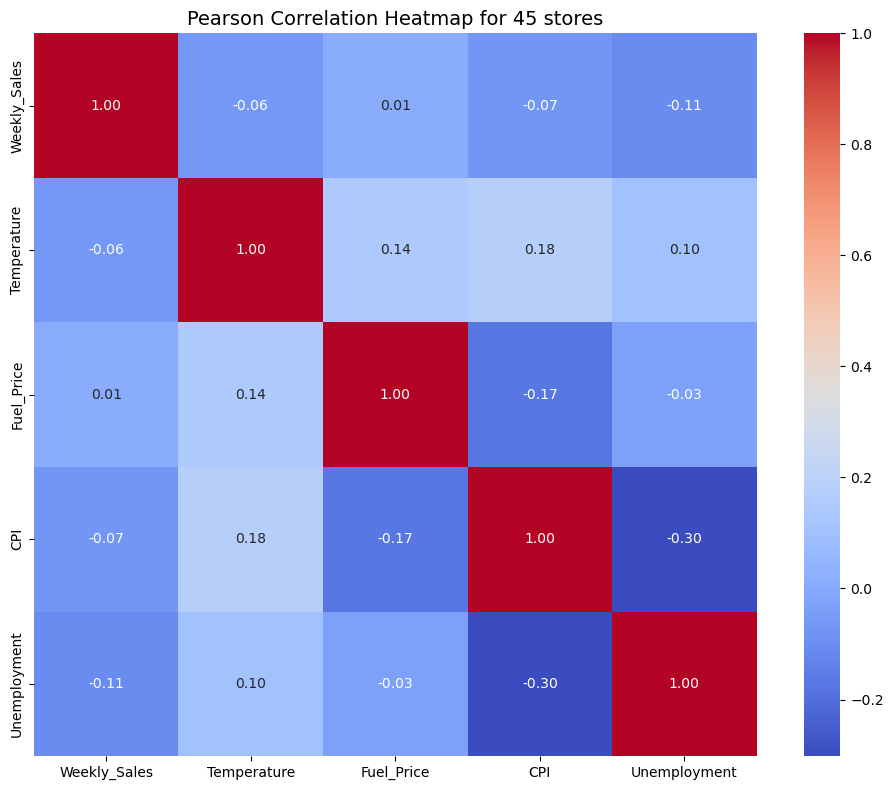

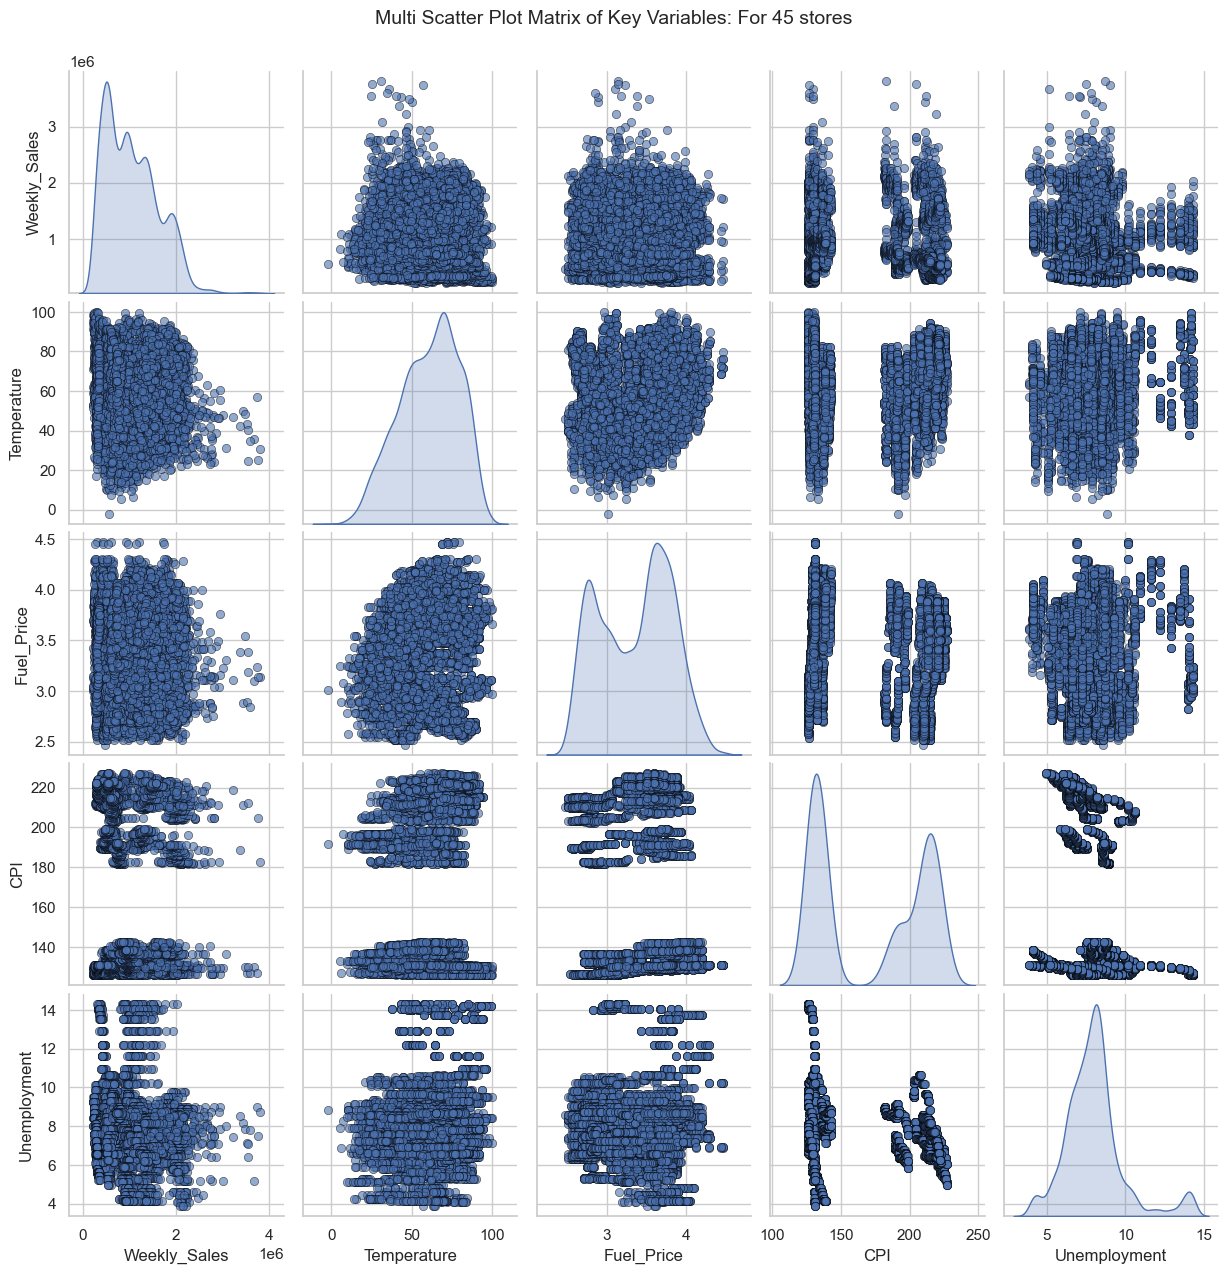

In [3]:
# Step 1: Import necessary libraries
# pandas is used for data handling
# seaborn and matplotlib are used for plotting
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load the cleaned Excel file
# This reads your Excel file into a DataFrame (a table-like structure)
file_path = "walmart-sales-dataset-of-45stores_cleaned.xlsx"
df = pd.read_excel(file_path)

# Step 3: Define the columns we want to analyze
# These are the numeric variables we want to explore visually
target_columns = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

# Step 4: Drop any rows with missing values in these columns
# This ensures that our plots are based on complete data only
df_clean = df[target_columns].dropna()

# Step 5: Compute the Pearson correlation matrix
# This shows how strongly each pair of variables is linearly related
correlation_matrix = df_clean.corr(method='pearson')

# Step 6: Plot the correlation heatmap
# This visualizes the correlation matrix using color intensity
plt.figure(figsize=(10, 8))  # Set the size of the heatmap
sns.heatmap(
    correlation_matrix,      # The correlation data
    annot=True,              # Show the correlation values
    cmap='coolwarm',         # Use a diverging color palette
    fmt=".2f",               # Format numbers to 2 decimal places
    square=True              # Make each cell square-shaped
)
plt.title("Pearson Correlation Heatmap for 45 stores", fontsize=14)  # Add a title
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()  # Display the heatmap

# Step 7: Create a multi scatter plot matrix using pairplot
# This shows scatter plots for each pair of variables and histograms on the diagonal
sns.set(style="whitegrid")  # Use a clean background style for plots

# Create the pairplot
pairplot = sns.pairplot(
    df_clean,                # The cleaned data
    diag_kind='kde',         # Use kernel density plots on the diagonal
    corner=False,            # Show full matrix (not just lower triangle)
    plot_kws={
        'alpha': 0.6,        # Set transparency of scatter points
        'edgecolor': 'black' # Add black outline to scatter points
    }
)

# Step 8: Add a title to the entire pairplot
# This gives context to the visual matrix
pairplot.fig.suptitle(
    "Multi Scatter Plot Matrix of Key Variables: For 45 stores",  # Title text
    fontsize=14,                                   # Font size
    y=1.02                                         # Position above the plot
)

# Step 9: Show the pairplot
plt.show()  # Display the scatter plot matrix

## High Level Sales Behavior View

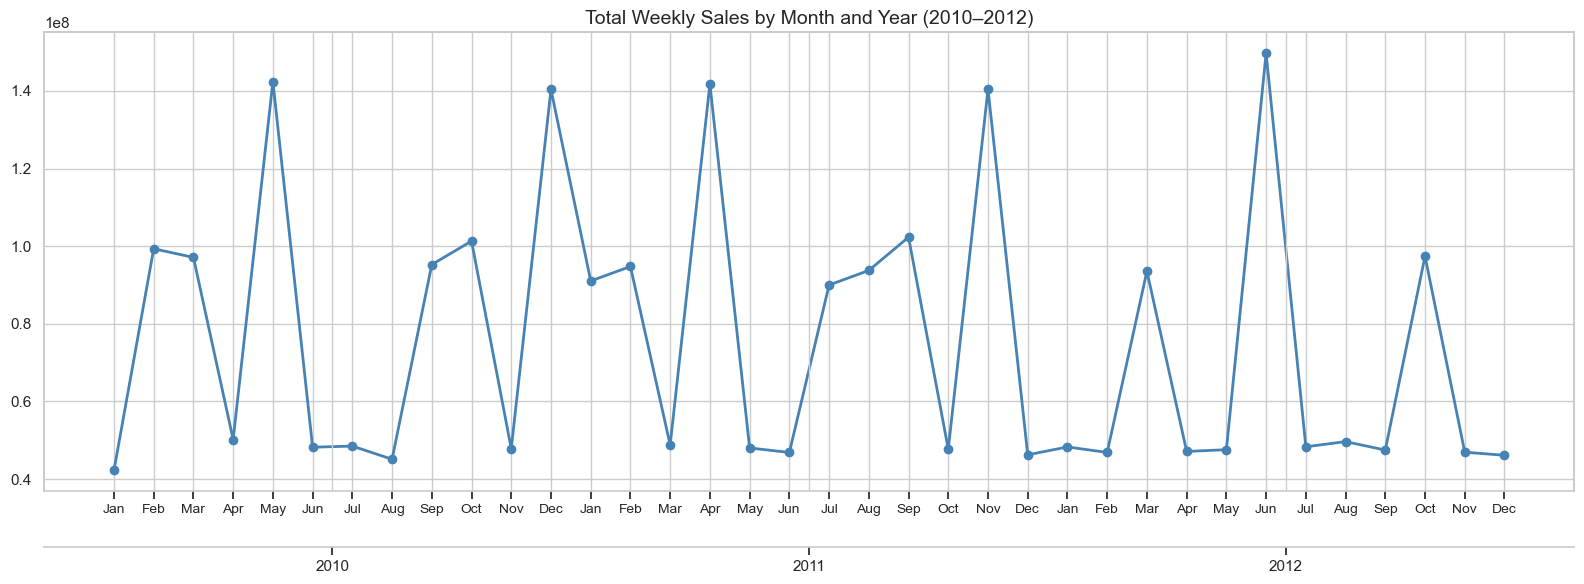

In [4]:
# Step 1: Import necessary libraries
# pandas for data handling, matplotlib for plotting
import pandas as pd
import matplotlib.pyplot as plt

# Step 2: Load the cleaned Excel file
# This reads your Excel file into a DataFrame (a table-like structure)
file_path = "walmart-sales-dataset-of-45stores_cleaned.xlsx"
df = pd.read_excel(file_path)

# Step 3: Convert the 'Date' column to datetime format
# This ensures we can extract month and year components
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Step 4: Filter the dataset to a 3-year period
# We'll keep only rows from 2010 to 2012
df = df[(df['Date'].dt.year >= 2010) & (df['Date'].dt.year <= 2012)]

# Step 5: Extract 'Month' and 'Year' from the 'Date' column
# We'll use these to group and label the X-axis
df['Month'] = df['Date'].dt.strftime('%b')   # Short month name like Jan, Feb
df['Year'] = df['Date'].dt.year              # Numeric year like 2010

# Step 6: Create a combined label for sorting and plotting
df['Month_Year'] = df['Month'] + '-' + df['Year'].astype(str)
df['Date_Order'] = pd.to_datetime(df['Month_Year'], format='%b-%Y')

# Step 7: Group the data by Year and Month
# We'll sum the Weekly_Sales to get total sales per month-year
monthly_sales = df.groupby(['Year', 'Month'], sort=False)['Weekly_Sales'].sum().reset_index()

# Step 8: Create a datetime column for sorting
monthly_sales['Month_Year'] = monthly_sales['Month'] + '-' + monthly_sales['Year'].astype(str)
monthly_sales['Date_Order'] = pd.to_datetime(monthly_sales['Month_Year'], format='%b-%Y')
monthly_sales = monthly_sales.sort_values('Date_Order')

# Step 9: Prepare the X and Y values for plotting
x_labels = monthly_sales['Month']            # Month names for inner X-axis
y_values = monthly_sales['Weekly_Sales']     # Total sales per month
years = monthly_sales['Year'].tolist()       # Year values for outer X-axis

# Step 10: Create the line plot
plt.figure(figsize=(16, 6))                  # Set the plot size
plt.plot(range(len(x_labels)), y_values, marker='o', color='steelblue', linewidth=2)

# Step 11: Customize the inner X-axis with month labels
plt.xticks(ticks=range(len(x_labels)), labels=x_labels, rotation=0, fontsize=10)

# Step 12: Add outer X-axis layer for year labels
# We'll place year labels once every 12 months, centered
ax = plt.gca()  # Get current axis
year_positions = []  # Store positions for year labels
year_labels = []     # Store year label text

# Loop through the index and find where each year starts
for i in range(0, len(monthly_sales), 12):
    midpoint = i + 5.5  # Center of the 12-month block
    year_positions.append(midpoint)
    year_labels.append(str(monthly_sales.iloc[i]['Year']))

# Step 13: Add year labels below the month labels
ax2 = ax.twiny()  # Create a twin axis sharing the same Y-axis
ax2.set_xlim(ax.get_xlim())  # Match the limits of the main axis
ax2.set_xticks(year_positions)  # Set year label positions
ax2.set_xticklabels(year_labels, fontsize=12)  # Set year label text
ax2.xaxis.set_ticks_position('bottom')  # Move ticks to bottom
ax2.xaxis.set_label_position('bottom')  # Move labels to bottom
ax2.spines['bottom'].set_position(('outward', 40))  # Offset the year axis

# Step 14: Add plot title and Y-axis label
plt.title("Total Weekly Sales by Month and Year (2010–2012)", fontsize=14)
plt.ylabel("Total Sales", fontsize=12)
plt.grid(True)  # Add grid lines for clarity
plt.tight_layout()  # Adjust layout to prevent clipping

# Step 15: Show the plot
plt.show()

## Total Sales In Annual View

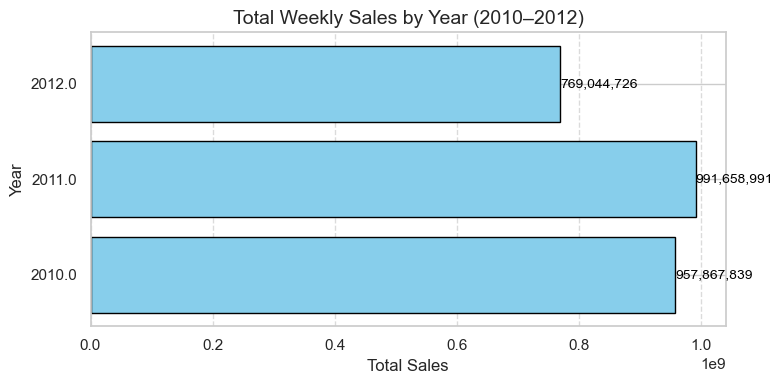

In [5]:
# Step 1: Import necessary libraries
# pandas for data handling, matplotlib for plotting
import pandas as pd
import matplotlib.pyplot as plt

# Step 2: Load the cleaned Excel file
# This reads your Excel file into a DataFrame (a table-like structure)
file_path = "walmart-sales-dataset-of-45stores_cleaned.xlsx"
df = pd.read_excel(file_path)

# Step 3: Convert the 'Date' column to datetime format
# This ensures we can extract the year component
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Step 4: Extract the 'Year' from the 'Date' column
# We'll use this to group sales by year
df['Year'] = df['Date'].dt.year

# Step 5: Filter the dataset to include only 2010, 2011, and 2012
df_filtered = df[df['Year'].isin([2010, 2011, 2012])]

# Step 6: Group the data by year and sum the Weekly_Sales
# This gives us total sales per year
yearly_sales = df_filtered.groupby('Year')['Weekly_Sales'].sum().reset_index()

# Step 7: Prepare the X and Y values for plotting
sales = yearly_sales['Weekly_Sales']       # Total sales values
years = yearly_sales['Year'].astype(str)   # Year labels as strings

# Step 8: Create the horizontal bar chart
plt.figure(figsize=(8, 4))                 # Set the plot size
bars = plt.barh(y=years, width=sales, color='skyblue', edgecolor='black')

# Step 9: Add quantity labels to each bar
# We'll loop through each bar and place a label at the end
for bar in bars:
    width = bar.get_width()  # Get the length of the bar
    y_pos = bar.get_y() + bar.get_height() / 2  # Vertical center of the bar
    plt.text(
        x=width + 50000,     # Position slightly to the right of the bar
        y=y_pos,             # Align vertically with the bar
        s=f"{int(width):,}", # Format the number with commas
        va='center',         # Vertically center the text
        fontsize=10,
        color='black'
    )

# Step 10: Customize the chart
plt.title("Total Weekly Sales by Year (2010–2012)", fontsize=14)
plt.xlabel("Total Sales", fontsize=12)
plt.ylabel("Year", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)  # Add horizontal grid lines
plt.tight_layout()                             # Adjust layout to prevent clipping

# Step 11: Show the chart
plt.show()

## Top 10 Stores for each year summary

In [6]:
# Step 1: Import necessary libraries
# pandas for data handling, tabulate for clean console output
import pandas as pd
from tabulate import tabulate

# Step 2: Load the cleaned Excel file
# This reads your Excel file into a DataFrame (a table-like structure)
file_path = "walmart-sales-dataset-of-45stores_cleaned.xlsx"
df = pd.read_excel(file_path)

# Step 3: Convert the 'Date' column to datetime format
# This ensures we can extract the year component
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Step 4: Extract the 'Year' from the 'Date' column
# We'll use this to filter and group sales by year
df['Year'] = df['Date'].dt.year

# Step 5: Filter the dataset to include only 2010, 2011, and 2012
df_filtered = df[df['Year'].isin([2010, 2011, 2012])]

# Step 6: Group the data by Year and Store
# We'll sum the Weekly_Sales to get total sales per store per year
grouped = df_filtered.groupby(['Year', 'Store'])['Weekly_Sales'].sum().reset_index()

# Step 7: Create an empty list to store formatted rows
summary_rows = []

# Step 8: Loop through each year and extract top 10 stores
for year in [2010, 2011, 2012]:
    # Filter data for the current year
    year_data = grouped[grouped['Year'] == year]

    # Sort by total sales in descending order
    top_stores = year_data.sort_values(by='Weekly_Sales', ascending=False).head(10)

    # Format each row and append to the summary list
    for i, row in enumerate(top_stores.itertuples()):
        # Only show the year label on the first row of each block
        year_label = str(year) if i == 0 else ""

        # Format store number as integer and sales as plain number with commas
        store_label = f"Store {int(row.Store)}"
        sales_label = f"{int(row.Weekly_Sales):,}"

        # Append the row
        summary_rows.append([year_label, store_label, sales_label])

# Step 9: Define column headers
headers = ["Year", "Store Name", "Total Sales"]

# Step 10: Print the tabulated summary
print("\nTop 10 Stores by Total Sales (2010–2012) Breakdown")
print(tabulate(summary_rows, headers=headers, tablefmt='grid'))


Top 10 Stores by Total Sales (2010–2012) Breakdown
+--------+--------------+---------------+
| Year   | Store Name   | Total Sales   |
+========+==============+===============+
| 2010   | Store 14     | 44,601,093    |
+--------+--------------+---------------+
|        | Store 20     | 43,327,214    |
+--------+--------------+---------------+
|        | Store 2      | 39,996,067    |
+--------+--------------+---------------+
|        | Store 13     | 39,405,255    |
+--------+--------------+---------------+
|        | Store 4      | 39,376,191    |
+--------+--------------+---------------+
|        | Store 10     | 39,018,575    |
+--------+--------------+---------------+
|        | Store 27     | 37,417,289    |
+--------+--------------+---------------+
|        | Store 6      | 32,239,415    |
+--------+--------------+---------------+
|        | Store 1      | 31,112,388    |
+--------+--------------+---------------+
|        | Store 19     | 30,619,106    |
+--------+--------------

## Screening stores that has the highest coefficient of determination

In [7]:
# Step 1: Import necessary libraries
# pandas for data handling, sklearn for regression, tabulate for clean output
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from tabulate import tabulate

# Step 2: Load the cleaned Excel file
# This reads your Excel file into a DataFrame (a table-like structure)
file_path = "walmart-sales-dataset-of-45stores_cleaned.xlsx"
df = pd.read_excel(file_path)

# Step 3: Convert the 'Date' column to datetime format
# This ensures we can extract the year component
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Step 4: Extract the 'Year' from the 'Date' column
# We'll use this to filter the data to a 3-year range
df['Year'] = df['Date'].dt.year

# Step 5: Filter the dataset to include only 2010, 2011, and 2012
df_filtered = df[df['Year'].isin([2010, 2011, 2012])]

# Step 6: Define the independent and dependent variables
# We'll use these for regression modeling
features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
target = 'Weekly_Sales'

# Step 7: Create an empty list to store R² results
r2_results = []

# Step 8: Loop through each store and perform regression
for store_id in df_filtered['Store'].unique():
    # Filter data for the current store
    store_data = df_filtered[df_filtered['Store'] == store_id]

    # Drop rows with missing values in relevant columns
    store_data = store_data[features + [target]].dropna()

    # Check if there's enough data to run regression
    if len(store_data) < 10:
        continue  # Skip stores with insufficient data

    # Prepare X and y for regression
    X = store_data[features]
    y = store_data[target]

    # Fit the linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Predict and calculate R² score
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)

    # Append results to the list
    r2_results.append([
        f"Store {int(store_id)}",       # Store label as integer
        f"{r2:.4f}"                     # R² value formatted to 4 decimals
    ])

# Step 9: Sort the results by R² in descending order
r2_sorted = sorted(r2_results, key=lambda x: float(x[1]), reverse=True)

# Step 10: Select the top 10 stores
top_10 = r2_sorted[:10]

# Step 11: Define column headers
headers = ["Store Name", "R² Value"]

# Step 12: Print the tabulated summary
print("\nTop 10 Stores by Coefficient of Determination (R²)")
print(tabulate(top_10, headers=headers, tablefmt='grid'))


Top 10 Stores by Coefficient of Determination (R²)
+--------------+------------+
| Store Name   |   R² Value |
+==============+============+
| Store 36     |     0.8529 |
+--------------+------------+
| Store 38     |     0.8177 |
+--------------+------------+
| Store 44     |     0.7769 |
+--------------+------------+
| Store 35     |     0.7142 |
+--------------+------------+
| Store 41     |     0.6205 |
+--------------+------------+
| Store 4      |     0.6084 |
+--------------+------------+
| Store 39     |     0.5377 |
+--------------+------------+
| Store 3      |     0.5338 |
+--------------+------------+
| Store 10     |     0.4381 |
+--------------+------------+
| Store 9      |     0.4272 |
+--------------+------------+


## Store 36' Pearson and Correlation Plots

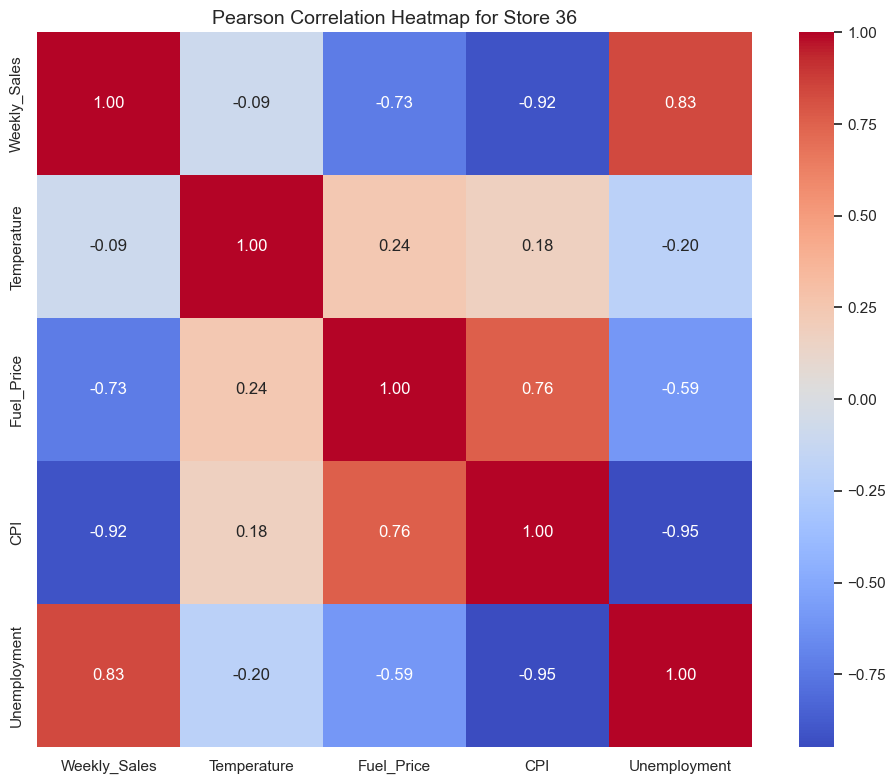

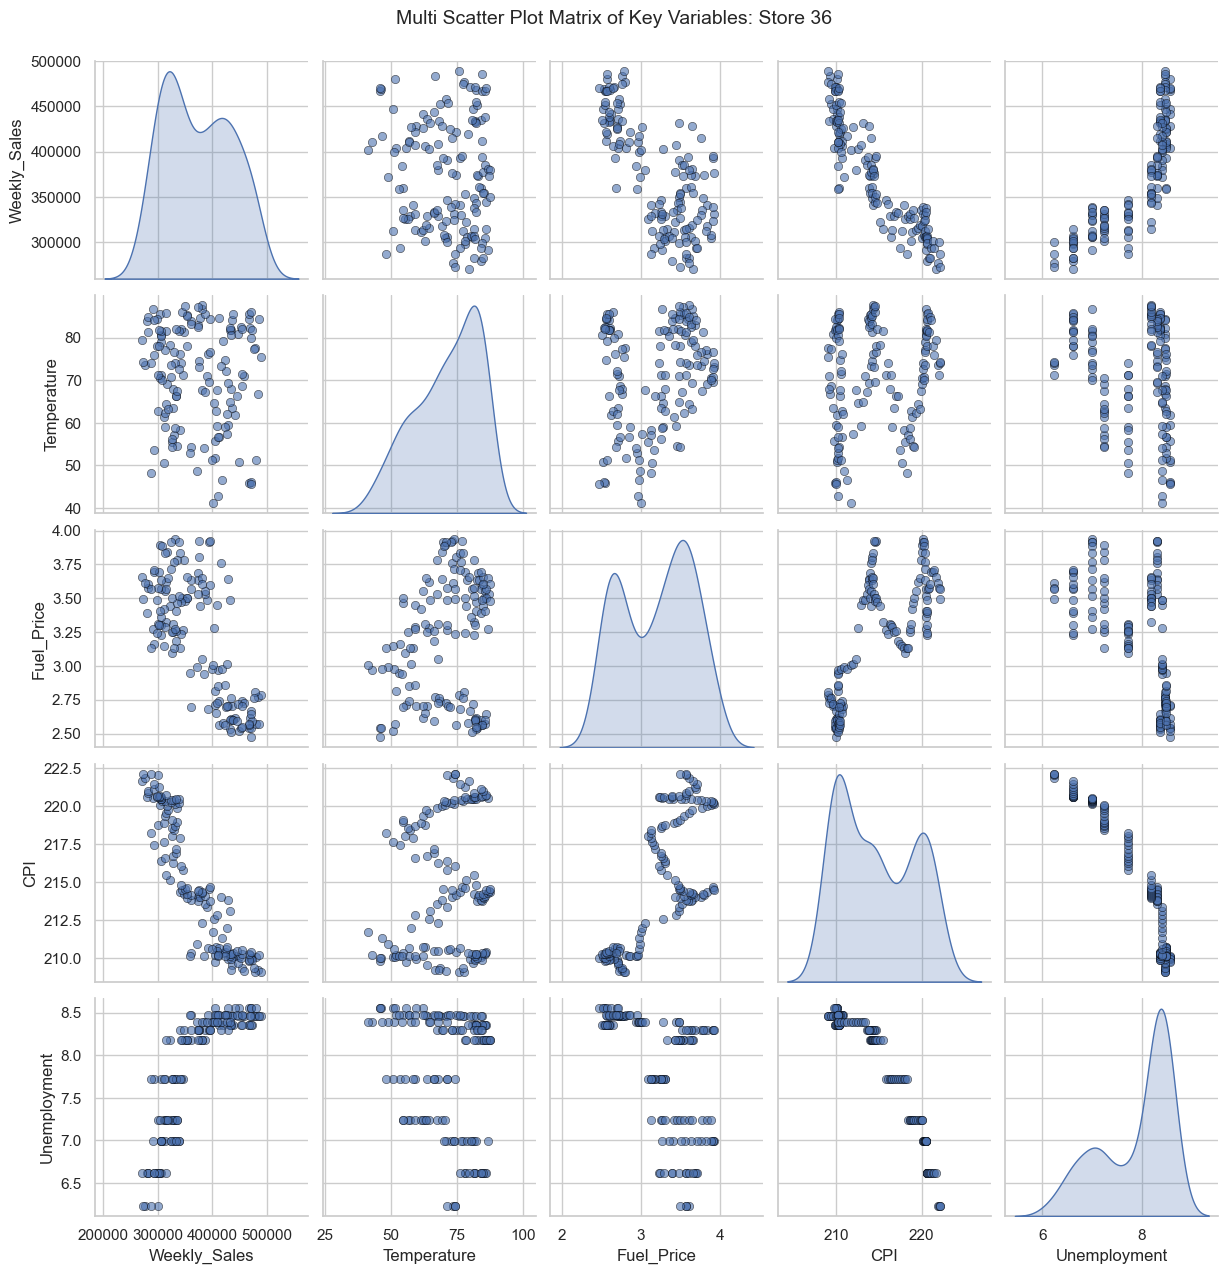

In [8]:
# Step 1: Import necessary libraries
# pandas is used for data handling
# seaborn and matplotlib are used for plotting
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load the cleaned Excel file
# This reads your Excel file into a DataFrame (a table-like structure)
file_path = "walmart-sales-dataset-of-45stores_cleaned.xlsx"
df = pd.read_excel(file_path)

# Step 3: Filter the dataset to include only Store 36
# This isolates the data for the store we're interested in
df_store36 = df[df['Store'] == 36]

# Step 4: Define the columns we want to analyze
# These are the numeric variables we want to explore visually
target_columns = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

# Step 5: Drop any rows with missing values in these columns
# This ensures that our plots are based on complete data only
df_clean = df_store36[target_columns].dropna()

# Step 6: Compute the Pearson correlation matrix
# This shows how strongly each pair of variables is linearly related
correlation_matrix = df_clean.corr(method='pearson')

# Step 7: Plot the correlation heatmap
# This visualizes the correlation matrix using color intensity
plt.figure(figsize=(10, 8))  # Set the size of the heatmap
sns.heatmap(
    correlation_matrix,      # The correlation data
    annot=True,              # Show the correlation values
    cmap='coolwarm',         # Use a diverging color palette
    fmt=".2f",               # Format numbers to 2 decimal places
    square=True              # Make each cell square-shaped
)
plt.title("Pearson Correlation Heatmap for Store 36", fontsize=14)  # Add a title
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()  # Display the heatmap

# Step 8: Create a multi scatter plot matrix using pairplot
# This shows scatter plots for each pair of variables and histograms on the diagonal
sns.set(style="whitegrid")  # Use a clean background style for plots

# Create the pairplot
pairplot = sns.pairplot(
    df_clean,                # The cleaned data for Store 36
    diag_kind='kde',         # Use kernel density plots on the diagonal
    corner=False,            # Show full matrix (not just lower triangle)
    plot_kws={
        'alpha': 0.6,        # Set transparency of scatter points
        'edgecolor': 'black' # Add black outline to scatter points
    }
)

# Step 9: Add a title to the entire pairplot
# This gives context to the visual matrix
pairplot.fig.suptitle(
    "Multi Scatter Plot Matrix of Key Variables: Store 36",  # Title text
    fontsize=14,                                   # Font size
    y=1.02                                         # Position above the plot
)

# Step 10: Show the pairplot
plt.show()  # Display the scatter plot matrix

In [ ]:
# Verify tabulate is available
import tabulate
print('tabulate version:', tabulate.__version__)